In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)

In [5]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,186.0,10.0,150.0,350.0,167.0,167.0,166.0
1,rpi-4a,16.2,17.4,1446.0,17.8,435.5,17.1,19.3
2,odroid1,165.0,167.0,167.0,168.0,169.0,166.0,168.0
3,odroid4,169.0,175.0,176.0,174.0,174.0,173.0,173.0
4,rpi-8c,24.9,629.1,16.7,2092.1,16.1,17.3,17.6


In [6]:
len(df)

18000

In [13]:
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 13000, 1000):
    train_data = df.head(i)
    test_data = df.tail(5000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality')
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels/ag-20241015_010432"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #45-Ubuntu SMP PREEMPT_DYNAMIC Fri Aug 30 12:02:04 UTC 2024
CPU Count:          12
Memory Avail:       27.60 GB / 30.82 GB (89.5%)
Disk Space Avail:   173.45 GB / 341.37 GB (50.8%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20241015_010432"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['rpi-8d', 'rpi-8c', 'odroid2', 'odroid4', 'rpi-8a', 'odroid3', 'rpi-8b', 'rpi-4a', 'odroid1']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type para

[1000]	valid_set's multi_error: 0.1725


	2.12s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.835	 = Validation score   (accuracy)
	1.13s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8175	 = Validation score   (accuracy)
	0.49s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.825	 = Validation score   (accuracy)
	0.44s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8025	 = Validation score   (accuracy)
	0.78s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8125	 = Validation score   (accuracy)
	0.44s	 = Training   

[1000]	valid_set's multi_error: 0.128


	0.878	 = Validation score   (accuracy)
	3.06s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.878	 = Validation score   (accuracy)
	1.49s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.868	 = Validation score   (accuracy)
	0.54s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.868	 = Validation score   (accuracy)
	0.44s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.842	 = Validation score   (accuracy)
	1.34s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.868	 = Validation sco

...

	0.891	 = Validation score   (accuracy)
	3.57s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.908	 = Validation score   (accuracy)
	2.29s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.876	 = Validation score   (accuracy)
	0.56s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.879	 = Validation score   (accuracy)
	0.49s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.865	 = Validation score   (accuracy)
	1.78s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.88	 = Validation sco

[1000]	valid_set's multi_error: 0.106364


	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.9027	 = Validation score   (accuracy)
	1.71s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8882	 = Validation score   (accuracy)
	0.6s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8945	 = Validation score   (accuracy)
	0.49s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8773	 = Validation score   (accuracy)
	1.96s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8891	 = Validation score   (accuracy)
	0.48s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.8873	 = Val

[1000]	valid_set's multi_error: 0.103333


	0.9042	 = Validation score   (accuracy)
	5.23s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.9092	 = Validation score   (accuracy)
	2.3s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8983	 = Validation score   (accuracy)
	0.58s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9008	 = Validation score   (accuracy)
	0.49s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8808	 = Validation score   (accuracy)
	1.79s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8925	 = Validati

In [14]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.834292,0.8332,0.832445
1,2000,0.850277,0.8502,0.849059
2,3000,0.861767,0.8618,0.861519
3,4000,0.869870,0.8704,0.869747
4,5000,0.879201,0.8796,0.878919
5,6000,0.878664,0.8792,0.878797
6,7000,0.888773,0.8886,0.888485
7,8000,0.892383,0.8922,0.891601
8,9000,0.897471,0.8980,0.897552
9,10000,0.897714,0.8984,0.897926


<Axes: xlabel='data_amount', ylabel='value'>

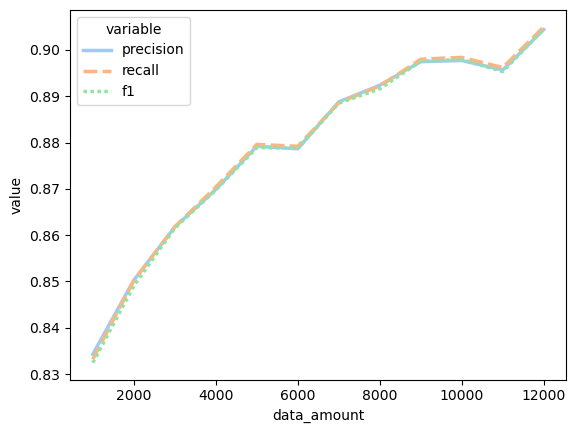

In [15]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [16]:
best_model

{'WeightedEnsemble_L2': 9,
 'LightGBM': 10,
 'RandomForestEntr': 7,
 'RandomForestGini': 8,
 'XGBoost': 1,
 'LightGBMLarge': 1}

([<matplotlib.patches.Wedge at 0x7543de1abf10>,
 [Text(0.7778174593052024, 0.7778174593052023, 'WeightedEnsemble_L2'),
  Text(-0.8426489168532446, 0.7070663355909783, 'LightGBM'),
  Text(-0.7778173864806728, -0.777817532129725, 'RandomForestEntr'),
  Text(0.5500001040567056, -0.9526278840857081, 'RandomForestGini'),
  Text(1.062518441682176, -0.2847008273350828, 'XGBoost'),
  Text(1.0958141790587292, -0.09587118948799789, 'LightGBMLarge')],
 [Text(0.4242640687119285, 0.42426406871192845, '25%'),
  Text(-0.45962668191995154, 0.3856725466859881, '28%'),
  Text(-0.4242640289894578, -0.42426410843439544, '19%'),
  Text(0.30000005675820307, -0.5196152095012952, '22%'),
  Text(0.5795555136448232, -0.1552913603645906, '3%'),
  Text(0.597716824941125, -0.052293376084362485, '3%')])

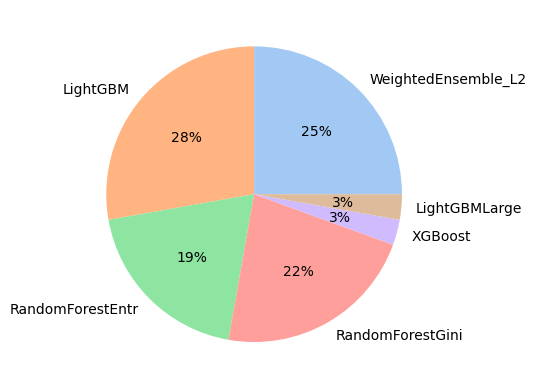

In [17]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [18]:
best_features

{'Feature 2': 12,
 'Feature 3': 5,
 'Feature 1': 12,
 'Feature 5': 2,
 'Feature 0': 4,
 'Feature 6': 1}

([<matplotlib.patches.Wedge at 0x7543de140df0>,
 [Text(0.5499999702695115, 0.9526279613277875, 'Feature 2'),
  Text(-0.9010673012266095, 0.6309340049959224, 'Feature 3'),
  Text(-0.7070662566964895, -0.8426489830535692, 'Feature 1'),
  Text(0.5500001598013667, -0.9526278519015026, 'Feature 5'),
  Text(0.9526280385698485, -0.5499998364823061, 'Feature 0'),
  Text(1.0958141846687952, -0.09587112536454294, 'Feature 6')],
 [Text(0.2999999837833699, 0.5196152516333385, '33%'),
  Text(-0.4914912552145142, 0.3441458209068668, '14%'),
  Text(-0.38567250365263056, -0.4596267180292195, '33%'),
  Text(0.3000000871643818, -0.519615191946274, '6%'),
  Text(0.5196152937653719, -0.29999991080853056, '11%'),
  Text(0.5977168280011609, -0.0522933411079325, '3%')])

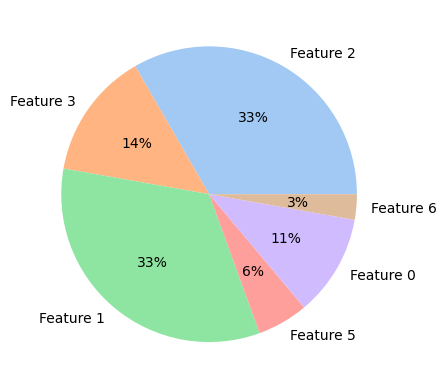

In [19]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')

In [20]:
feature_importance

,importance,stddev,p_value,n,p99_high,p99_low
Feature 2,0.13772,0.005900,4.032636e-07,5,0.149869,0.125571
Feature 1,0.10076,0.002559,4.987381e-08,5,0.106029,0.095491
Feature 3,0.08384,0.001519,1.293176e-08,5,0.086968,0.080712
Feature 0,0.07640,0.003586,5.807845e-07,5,0.083784,0.069016
Feature 6,0.07248,0.003431,6.007760e-07,5,0.079545,0.065415
Feature 5,0.06104,0.001014,9.131658e-09,5,0.063128,0.058952
Feature 4,0.04652,0.002129,5.247960e-07,5,0.050903,0.042137


In [14]:
train_data = df.head(10000)
test_data = df.tail(8000)

predictor = TabularPredictor(label='label', eval_metric='log_loss').fit(train_data, num_gpus=1, presets='good_quality', time_limit=3600)
y_pred = predictor.predict(test_data)
y_pred_proba = predictor.predict_proba(test_data)
results = predictor.evaluate(test_data, detailed_report=True)

No path specified. Models will be saved in: "AutogluonModels/ag-20241101_073412"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.11.10
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #48-Ubuntu SMP PREEMPT_DYNAMIC Fri Sep 27 14:04:52 UTC 2024
CPU Count:          28
Memory Avail:       27.28 GB / 30.81 GB (88.5%)
Disk Space Avail:   149.22 GB / 341.37 GB (43.7%)
Presets specified: ['good_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
DySt

In [15]:
results

{'log_loss': -0.25845703413057214,
 'accuracy': 0.89675,
 'balanced_accuracy': 0.8968594077435816,
 'mcc': 0.883877043783628,
 'confusion_matrix':          odroid1  odroid2  odroid3  odroid4  rpi-4a  rpi-8a  rpi-8b  rpi-8c  \
 odroid1      875        0       30        0       0       0       0       1   
 odroid2        3      878        4        1       0       0       0       0   
 odroid3       33        3      872        7       0       0       0       0   
 odroid4        0        0        3      877       0       0       0       0   
 rpi-4a         0        0        0        0     774       0       7      40   
 rpi-8a         0        0        0        0       0     802      81       1   
 rpi-8b         0        0        0        0       0      81     786       1   
 rpi-8c         0        0        0        0      50       2      13     659   
 rpi-8d         0        0        0        0      71       4       6     179   
 
          rpi-8d  
 odroid1       0  
 odroid2      

In [16]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,-0.272940,log_loss,3.319105,539.439822,0.002110,1.089705,3,False,24
1,ExtraTreesGini_BAG_L2,-0.281500,log_loss,2.354031,304.802197,0.183459,0.354598,2,False,19
2,CatBoost_BAG_L2,-0.283061,log_loss,2.215236,447.045259,0.044664,142.597660,2,False,18
3,ExtraTreesEntr_BAG_L2,-0.285668,log_loss,2.359912,304.794546,0.189339,0.346946,2,False,20
4,LightGBMXT_BAG_L2,-0.286337,log_loss,2.270508,309.710770,0.099935,5.263170,2,False,14
5,NeuralNetFastAI_BAG_L2,-0.288554,log_loss,2.234527,325.076605,0.063955,20.629005,2,False,13
6,RandomForestGini_BAG_L2,-0.290923,log_loss,2.364797,305.148226,0.194225,0.700626,2,False,16
7,WeightedEnsemble_L2,-0.291806,log_loss,0.590137,106.313195,0.002069,0.581562,2,False,12
8,NeuralNetTorch_BAG_L2,-0.294208,log_loss,2.531995,368.365319,0.361423,63.917719,2,False,22
9,RandomForestEntr_BAG_L2,-0.298120,log_loss,2.374221,305.241019,0.203648,0.793419,2,False,17


In [17]:
# will return the path to the cloned predictor, identical to save_path_clone_opt
path_clone_opt = predictor.clone_for_deployment(path='classification')

Cloned TabularPredictor located in 'AutogluonModels/ag-20241101_073412' to 'classification'.
	To load the cloned predictor: predictor_clone = TabularPredictor.load(path="classification")
Clone: Keeping minimum set of models required to predict with best model 'WeightedEnsemble_L3_FULL'...
Deleting model NeuralNetFastAI_BAG_L1. All files under classification/models/NeuralNetFastAI_BAG_L1 will be removed.
Deleting model LightGBMXT_BAG_L1. All files under classification/models/LightGBMXT_BAG_L1 will be removed.
Deleting model LightGBM_BAG_L1. All files under classification/models/LightGBM_BAG_L1 will be removed.
Deleting model RandomForestGini_BAG_L1. All files under classification/models/RandomForestGini_BAG_L1 will be removed.
Deleting model RandomForestEntr_BAG_L1. All files under classification/models/RandomForestEntr_BAG_L1 will be removed.
Deleting model CatBoost_BAG_L1. All files under classification/models/CatBoost_BAG_L1 will be removed.
Deleting model ExtraTreesGini_BAG_L1. All 

In [18]:
predictor_clone_opt = TabularPredictor.load(path='classification')

In [19]:
predictor_clone_opt.leaderboard(test_data)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3_FULL,-0.258457,None,log_loss,0.903575,NaN,67.188084,0.004008,NaN,1.089705,3,True,19
1,LightGBMXT_BAG_L2_FULL,-0.262074,None,log_loss,0.535472,NaN,46.454468,0.018963,NaN,1.000624,2,True,13
2,CatBoost_BAG_L2_FULL,-0.262842,None,log_loss,0.524208,NaN,57.944929,0.007699,NaN,12.491084,2,True,15
3,ExtraTreesEntr_BAG_L2_FULL,-0.264218,None,log_loss,0.577846,NaN,45.800790,0.061337,0.189339,0.346946,2,True,17
4,ExtraTreesGini_BAG_L2_FULL,-0.266163,None,log_loss,0.576131,NaN,45.808442,0.059623,0.183459,0.354598,2,True,16
5,RandomForestEntr_BAG_L2_FULL,-0.271369,None,log_loss,0.575103,NaN,46.247263,0.058594,0.203648,0.793419,2,True,14
6,NeuralNetFastAI_BAG_L2_FULL,-0.276025,None,log_loss,0.565535,NaN,47.808657,0.049026,NaN,2.354813,2,True,12
7,NeuralNetTorch_BAG_L2_FULL,-0.280046,None,log_loss,0.644324,NaN,48.756895,0.127815,NaN,3.303051,2,True,18
8,LightGBM_BAG_L1_FULL,-0.281368,None,log_loss,0.022446,NaN,0.947886,0.022446,NaN,0.947886,1,True,3
9,XGBoost_BAG_L1_FULL,-0.286866,None,log_loss,0.029741,NaN,0.817327,0.029741,NaN,0.817327,1,True,9


In [20]:
size_original = predictor.disk_usage()
size_opt = predictor_clone_opt.disk_usage()
print(f'Size Original:  {size_original} bytes')
print(f'Size Optimized: {size_opt} bytes')
print(f'Optimized predictor achieved a {round((1 - (size_opt/size_original)) * 100, 1)}% reduction in disk usage.')

Size Original:  910871344 bytes
Size Optimized: 427523098 bytes
Optimized predictor achieved a 53.1% reduction in disk usage.


*** SIGTERM received at time=1730452320 on cpu 9 ***
PC: @     0x77d8e232a042  (unknown)  epoll_wait
    @     0x77d8e2245320  (unknown)  (unknown)
    @     0x77d8e2903c52  (unknown)  select_epoll_poll_impl
[2024-11-01 20:12:00,674 E 1466 1466] logging.cc:361: *** SIGTERM received at time=1730452320 on cpu 9 ***
[2024-11-01 20:12:00,674 E 1466 1466] logging.cc:361: PC: @     0x77d8e232a042  (unknown)  epoll_wait
[2024-11-01 20:12:00,675 E 1466 1466] logging.cc:361:     @     0x77d8e2245320  (unknown)  (unknown)
[2024-11-01 20:12:00,675 E 1466 1466] logging.cc:361:     @     0x77d8e2903c52  (unknown)  select_epoll_poll_impl
